# Module 1 — XGBoost Damage Prediction & SHAP Equity Analysis
## LA Wildfire Risk 2025: Palisades & Eaton Fires

**Author:** Sophia Hert  
**Data:** CAL FIRE Damage Inspection Program (DINS), ACS 2021–2022, Census TIGER 2023  
**Environment:** Python 3.10+ / Google Colab  

### What this notebook does
1. Loads and cleans the CAL FIRE DINS parcel records for the 2025 Palisades and Eaton fires
2. Engineers structural and socioeconomic features
3. Runs pre-modelling diagnostics: multicollinearity heatmap, class balance, feature variance audit
4. Trains an XGBoost binary classifier (destroyed vs. not destroyed)
5. Evaluates via 5-fold stratified cross-validation (ROC-AUC, F1, RMSEC vs RMSEP overfitting check)
6. Decomposes predictions with SHAP TreeExplainer
7. Quantifies the equity gap in conditional destruction rates by income quintile
8. Exports clean outputs for Modules 2 and 3

### Methodological notes for reviewers
- **Class balance**
- **Multicollinearity**
- **Overfitting**
- **Feature encoding**:
- **Spatial autocorrelation**
- **Reflection problem**
- **Interpretability**
---


## 0. Setup

In [1]:
!pip install -q xgboost shap geopandas pyogrio shapely matplotlib seaborn scikit-learn requests

In [2]:
import os, sys, warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score, mean_squared_error
)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs('outputs', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('Packages loaded.')
print(f'  XGBoost   {xgb.__version__}')
print(f'  SHAP      {shap.__version__}')
print(f'  pandas    {pd.__version__}')
print(f'  GeoPandas {gpd.__version__}')

Packages loaded.
  XGBoost   3.2.0
  SHAP      0.51.0
  pandas    2.2.2
  GeoPandas 1.1.3


In [3]:
# ── Mount Google Drive & set paths ────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = '/content/drive/MyDrive/WildFire'
    DINS_PATH  = f'{DRIVE_BASE}/POSTFIRE_MASTER_DATA_SHARE_795979837499149141.csv'
    TRACT_PATH = f'{DRIVE_BASE}/tl_2023_06_tract/tl_2023_06_tract.shp'
else:
    DINS_PATH  = '../data/raw/POSTFIRE_MASTER_DATA_SHARE.csv'
    TRACT_PATH = '../data/raw/tl_2023_06_tract/tl_2023_06_tract.shp'

# Census API key — set as environment variable, never hardcode in committed files
# Terminal: export CENSUS_API_KEY='your_key'
CENSUS_KEY = os.environ.get('CENSUS_API_KEY', 'Enter Key Here')

print(f'DINS path  : {DINS_PATH}')
print(f'Tract path : {TRACT_PATH}')
print(f'Census key : {"set" if CENSUS_KEY != "Enter Key Here" else "NOT SET — set env var CENSUS_API_KEY"}')

Mounted at /content/drive
DINS path  : /content/drive/MyDrive/WildFire/POSTFIRE_MASTER_DATA_SHARE_795979837499149141.csv
Tract path : /content/drive/MyDrive/WildFire/tl_2023_06_tract/tl_2023_06_tract.shp
Census key : set


## 1. Load & filter DINS parcel data

In [4]:
dins_raw = pd.read_csv(DINS_PATH, encoding='utf-8-sig', low_memory=False)
print(f'Full DINS dataset : {len(dins_raw):,} records | {dins_raw.shape[1]} columns')

TARGET_FIRES = ['Palisades', 'Eaton']
dins = dins_raw[dins_raw['* Incident Name'].isin(TARGET_FIRES)].copy()
dins = dins.reset_index(drop=True)

print(f'2025 LA fire records : {len(dins):,}')
print('\nRecords per fire:')
print(dins['* Incident Name'].value_counts().to_string())
print('\nDamage category distribution:')
print(dins['* Damage'].value_counts().to_string())

Full DINS dataset : 132,522 records | 47 columns
2025 LA fire records : 30,565

Records per fire:
* Incident Name
Eaton        18428
Palisades    12137

Damage category distribution:
* Damage
Destroyed (>50%)     16264
No Damage            12154
Affected (>0-10%)     1590
Minor (10-25%)         319
Major (25-50%)         142
Inaccessible            96


## 2. Feature engineering

> **Critical implementation note:** Structural categorical features are label-encoded HERE
> on the full `dins` DataFrame BEFORE the spatial join. GeoPandas `sjoin` can silently drop
> columns not present in the geometry DataFrame. Encoding first and verifying column survival
> after join is essential. Without this fix the model predicts from income proxies only.

In [5]:
# ── Target variable ───────────────────────────────────────────────────────────
damage_map = {
    'No Damage'         : 0,
    'Affected (>0-10%)' : 1,
    'Minor (10-25%)'    : 2,
    'Major (25-50%)'    : 3,
    'Destroyed (>50%)'  : 4,
    'Inaccessible'      : np.nan   # excluded — unobserved outcome
}
dins['damage_score'] = dins['* Damage'].map(damage_map)
dins['is_destroyed'] = (dins['damage_score'] == 4).astype('Int64')

vc = dins['is_destroyed'].value_counts(dropna=True)
print('Target distribution (excluding Inaccessible):')
print(vc.to_string())
print(f'Overall destruction rate  : {dins["is_destroyed"].mean()*100:.1f}%')
print(f'Class ratio (neg/pos)     : {vc[0]/vc[1]:.3f}  — near-balanced')

Target distribution (excluding Inaccessible):
is_destroyed
1    16264
0    14301
Overall destruction rate  : 53.2%
Class ratio (neg/pos)     : 0.879  — near-balanced


In [6]:
# ── Structural categorical features — encode BEFORE spatial join ──────────────
CAT_FEATURES = [
    '* Eaves',
    '* Vent Screen',
    '* Window Pane',
    '* Roof Construction',
    '* Exterior Siding',
    '* Deck/Porch On Grade',
    '* Deck/Porch Elevated',
    '* Patio Cover/Carport Attached to Structure',
    '* Fence Attached to Structure',
    '* Structure Type',
]
ENC_COLS = [col + '_enc' for col in CAT_FEATURES]

encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    dins[col + '_enc'] = le.fit_transform(dins[col].fillna('Unknown').astype(str))
    encoders[col] = le
    cats = ', '.join(le.classes_[:3])
    print(f'  {col.replace("* ",""):45s} {len(le.classes_):2d} cats  [{cats}...]')

  Eaves                                          5 cats  [Combustible, Enclosed, No Eaves...]
  Vent Screen                                    6 cats  [Attached Fence, Mesh Screen <= 1/8"", Mesh Screen > 1/8""...]
  Window Pane                                    5 cats  [Asphalt, Multi Pane, No Windows...]
  Roof Construction                              9 cats  [Asphalt, Combustible, Concrete...]
  Exterior Siding                                6 cats  [Metal, Other, Stucco Brick Cement...]
  Deck/Porch On Grade                            5 cats  [Composite, Masonry/Concrete, No Deck/Porch...]
  Deck/Porch Elevated                            5 cats  [Composite, Masonry/Concrete, No Deck/Porch...]
  Patio Cover/Carport Attached to Structure      4 cats  [Combustible, No Patio Cover/Carport, Non Combustible...]
  Fence Attached to Structure                    4 cats  [Combustible, No Fence, Non Combustible...]
  Structure Type                                16 cats  [Church, Commercial 

In [7]:
# ── Continuous features ───────────────────────────────────────────────────────
dins['Year Built (parcel)'] = pd.to_numeric(dins['Year Built (parcel)'], errors='coerce')
dins['struct_age']  = (2025 - dins['Year Built (parcel)']).clip(0, 150)
dins['post_2008']   = (dins['Year Built (parcel)'] >= 2008).astype('Int64')

dins['Assessed Improved Value (parcel)'] = pd.to_numeric(
    dins['Assessed Improved Value (parcel)'], errors='coerce'
)
dins['log_assessed_value'] = np.log1p(dins['Assessed Improved Value (parcel)'].clip(lower=0))

dins['is_eaton']  = (dins['* Incident Name'] == 'Eaton').astype(int)
dins['Latitude']  = pd.to_numeric(dins['Latitude'],  errors='coerce')
dins['Longitude'] = pd.to_numeric(dins['Longitude'], errors='coerce')

print('Continuous features summary:')
print(dins[['struct_age', 'post_2008', 'log_assessed_value', 'is_eaton']].describe().round(2).to_string())

Continuous features summary:
       struct_age  post_2008  log_assessed_value   is_eaton
count  30565.0000 30565.0000          30565.0000 30565.0000
mean      75.6300     0.0200             12.0700     0.6000
std       27.0400     0.1500              2.2600     0.4900
min        3.0000     0.0000              0.0000     0.0000
25%       64.0000     0.0000             11.6400     0.0000
50%       77.0000     0.0000             12.3100     1.0000
75%       95.0000     0.0000             13.0400     1.0000
max      150.0000     1.0000             20.0700     1.0000


## 3. Pre-modelling diagnostics

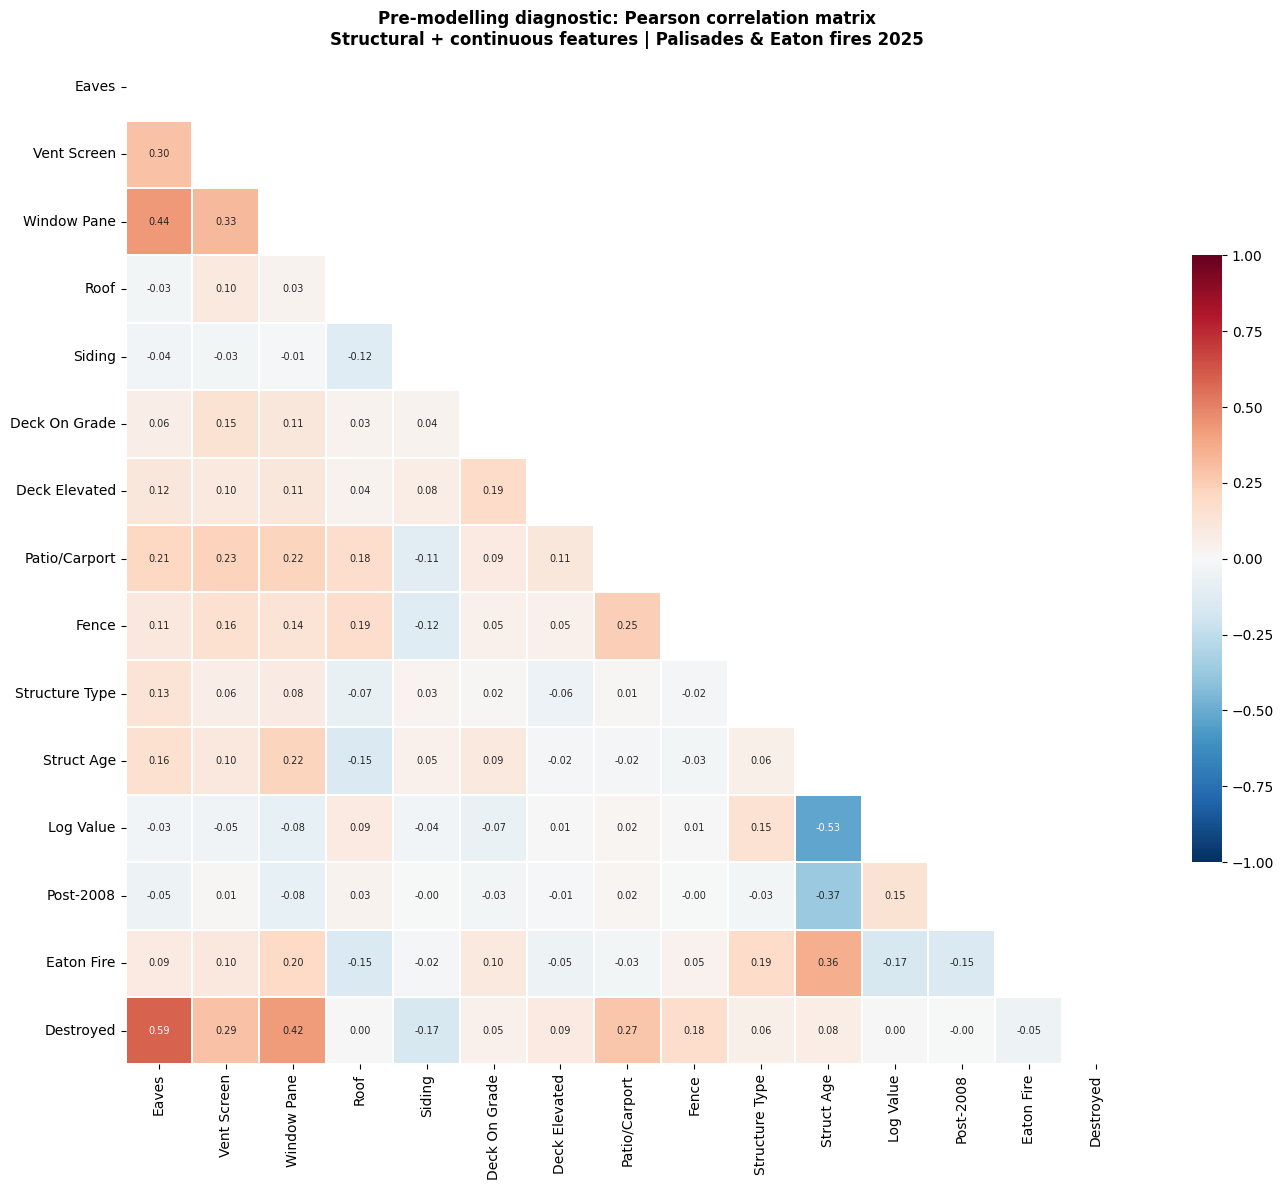

High correlations (|r| > 0.7):
  None — multicollinearity not a concern.


In [8]:
# ── 3a. Multicollinearity heatmap ─────────────────────────────────────────────
# Expected: income proxies correlated with each other.
# Key check: structural features should be largely independent of income proxies.
# If they correlate moderately, that is the thesis argument: construction quality
# (captured by structural features) is correlated with income but not identical to it.

CONT_COLS = ['struct_age', 'log_assessed_value', 'post_2008', 'is_eaton']
diag_df   = dins[ENC_COLS + CONT_COLS + ['is_destroyed']].dropna()
corr      = diag_df.corr()

short = {
    '* Eaves_enc': 'Eaves', '* Vent Screen_enc': 'Vent Screen',
    '* Window Pane_enc': 'Window Pane', '* Roof Construction_enc': 'Roof',
    '* Exterior Siding_enc': 'Siding', '* Deck/Porch On Grade_enc': 'Deck On Grade',
    '* Deck/Porch Elevated_enc': 'Deck Elevated',
    '* Patio Cover/Carport Attached to Structure_enc': 'Patio/Carport',
    '* Fence Attached to Structure_enc': 'Fence',
    '* Structure Type_enc': 'Structure Type',
    'struct_age': 'Struct Age', 'log_assessed_value': 'Log Value',
    'post_2008': 'Post-2008', 'is_eaton': 'Eaton Fire', 'is_destroyed': 'Destroyed'
}
corr.index   = [short.get(c, c) for c in corr.index]
corr.columns = [short.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6}
)
ax.set_title(
    'Pre-modelling diagnostic: Pearson correlation matrix\n'
    'Structural + continuous features | Palisades & Eaton fires 2025',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figures/00_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr = [
    (corr.index[i], corr.columns[j], corr.iloc[i, j])
    for i in range(len(corr)) for j in range(i)
    if abs(corr.iloc[i, j]) > 0.7
]
print('High correlations (|r| > 0.7):')
if high_corr:
    for a, b, r in high_corr:
        print(f'  {a} × {b} : r = {r:.3f}')
else:
    print('  None — multicollinearity not a concern.')

In [9]:
# ── 3b. Feature variance audit ────────────────────────────────────────────────
var_audit = diag_df[ENC_COLS + CONT_COLS].std().sort_values()
print('Feature standard deviations (ascending — low variance = potential noise):')
print(var_audit.round(4).to_string())
low_var = var_audit[var_audit < 0.01]
if len(low_var):
    print(f'\nLow-variance features: {list(low_var.index)} — consider removing.')
else:
    print('\nAll features have sufficient variance.')

Feature standard deviations (ascending — low variance = potential noise):
post_2008                                          0.1526
is_eaton                                           0.4893
* Deck/Porch On Grade_enc                          0.7430
* Deck/Porch Elevated_enc                          0.8154
* Fence Attached to Structure_enc                  0.9283
* Patio Cover/Carport Attached to Structure_enc    0.9396
* Eaves_enc                                        1.0227
* Vent Screen_enc                                  1.0525
* Exterior Siding_enc                              1.0990
* Window Pane_enc                                  1.1966
* Structure Type_enc                               2.1593
log_assessed_value                                 2.2620
* Roof Construction_enc                            2.8016
struct_age                                        27.0389

All features have sufficient variance.


## 4. Census ACS income data

In [10]:
def fetch_acs(year: int, key: str) -> pd.DataFrame:
    """
    Fetch ACS 5-year estimates for LA County (FIPS 037).
    Variables: B19013 (median HH income), B25077 (median home value), B25064 (median gross rent).
    Negative Census sentinel values recoded to NaN.
    """
    url = (
        f'https://api.census.gov/data/{year}/acs/acs5'
        f'?get=B19013_001E,B25077_001E,B25064_001E,NAME'
        f'&for=tract:*&in=state:06%20county:037&key={key}'
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    df['GEOID'] = (df['state'] + df['county'] + df['tract']).str.zfill(11)
    df = df.rename(columns={
        'B19013_001E': 'median_hh_income',
        'B25077_001E': 'median_home_value',
        'B25064_001E': 'median_gross_rent',
    })
    for col in ['median_hh_income', 'median_home_value', 'median_gross_rent']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df.loc[df[col] < 0, col] = np.nan
    df['year'] = year
    return df[['GEOID', 'year', 'median_hh_income', 'median_home_value', 'median_gross_rent']]


print('Fetching ACS 2021 and 2022 (both pre-fire — January 2025 fires)...')
acs_2021   = fetch_acs(2021, CENSUS_KEY)
acs_2022   = fetch_acs(2022, CENSUS_KEY)
acs_panel  = pd.concat([acs_2021, acs_2022], ignore_index=True)
acs_2022_join = acs_2022.copy()

print(f'ACS 2021 : {len(acs_2021):,} tracts')
print(f'ACS 2022 : {len(acs_2022):,} tracts')
print(f'\nACS 2022 median HH income summary:')
print(acs_2022['median_hh_income'].describe().round(0).to_string())

Fetching ACS 2021 and 2022 (both pre-fire — January 2025 fires)...
ACS 2021 : 2,498 tracts
ACS 2022 : 2,498 tracts

ACS 2022 median HH income summary:
count     2449.0000
mean     89334.0000
std      39567.0000
min       9417.0000
25%      61394.0000
50%      81972.0000
75%     108224.0000
max     250001.0000


## 5. Spatial join — assign census tract to each parcel

In [11]:
tracts_raw = gpd.read_file(TRACT_PATH)
la_tracts  = tracts_raw[tracts_raw['COUNTYFP'] == '037'].copy().to_crs('EPSG:4326')
la_tracts['GEOID'] = la_tracts['GEOID'].str.zfill(11)
la_tracts  = la_tracts.merge(acs_2022_join, on='GEOID', how='left')

print(f'LA County tracts          : {len(la_tracts):,}')
print(f'Tracts with income data   : {la_tracts["median_hh_income"].notna().sum():,}')

LA County tracts          : 2,498
Tracts with income data   : 2,449


In [12]:
# Convert DINS to GeoDataFrame
dins_valid = dins.dropna(subset=['Latitude', 'Longitude']).copy()
dins_geo   = gpd.GeoDataFrame(
    dins_valid,
    geometry=gpd.points_from_xy(dins_valid['Longitude'], dins_valid['Latitude']),
    crs='EPSG:4326'
)

# Spatial join
dins_joined = gpd.sjoin(
    dins_geo,
    la_tracts[['GEOID', 'median_hh_income', 'median_home_value', 'median_gross_rent', 'geometry']],
    how='left', predicate='within'
).drop(columns=['index_right'], errors='ignore')

# Verify structural features survived the join
enc_present = [c for c in ENC_COLS if c in dins_joined.columns]
print(f'Parcels with coordinates       : {len(dins_geo):,}')
print(f'Parcels with GEOID             : {dins_joined["GEOID"].notna().sum():,}')
print(f'Structural columns after join  : {len(enc_present)}/{len(ENC_COLS)}', end='')
print('  OK' if len(enc_present) == len(ENC_COLS) else '  WARNING — some structural columns missing!')

Parcels with coordinates       : 30,565
Parcels with GEOID             : 30,565
Structural columns after join  : 10/10  OK


In [13]:
# ── Income quintiles (LA County baseline distribution) ────────────────────────
county_income   = acs_2022_join['median_hh_income'].dropna()
quintile_bins   = county_income.quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
quintile_labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)']

dins_joined['income_quintile']     = pd.cut(
    dins_joined['median_hh_income'], bins=quintile_bins,
    labels=quintile_labels, include_lowest=True
)
dins_joined['income_quintile_num'] = dins_joined['income_quintile'].cat.codes + 1

print('LA County quintile income boundaries:')
for i, (lo, hi) in enumerate(zip(quintile_bins[:-1], quintile_bins[1:])):
    n = dins_joined[dins_joined['income_quintile'] == quintile_labels[i]].shape[0]
    print(f'  {quintile_labels[i]:15s}  ${lo:>8,.0f} – ${hi:>8,.0f}   ({n:,} parcels in fire zone)')

LA County quintile income boundaries:
  Q1 (lowest)      $   9,417 – $  57,465   (0 parcels in fire zone)
  Q2               $  57,465 – $  73,488   (1,675 parcels in fire zone)
  Q3               $  73,488 – $  91,236   (175 parcels in fire zone)
  Q4               $  91,236 – $ 115,280   (716 parcels in fire zone)
  Q5 (highest)     $ 115,280 – $ 250,001   (27,999 parcels in fire zone)


## 6. Build feature matrix

In [14]:
FEATURE_COLS = (
    ENC_COLS +
    ['struct_age', 'post_2008', 'log_assessed_value', 'is_eaton',
     'median_hh_income', 'median_home_value', 'median_gross_rent']
)
FEATURE_COLS = [f for f in FEATURE_COLS if f in dins_joined.columns]

model_df = dins_joined[
    FEATURE_COLS + ['is_destroyed', 'income_quintile', 'income_quintile_num', 'GEOID']
].dropna(subset=FEATURE_COLS + ['is_destroyed']).copy()

X = model_df[FEATURE_COLS].values.astype(float)
y = model_df['is_destroyed'].values.astype(int)

feature_names_clean = [
    col.replace('* ', '').replace('_enc', '').replace('_', ' ').title()
    for col in FEATURE_COLS
]

structural_names = [
    col.replace('* ', '').replace('_enc', '').replace('_', ' ').title()
    for col in ENC_COLS
]

print(f'Feature matrix shape : {X.shape}')
print(f'Structural features  : {len(ENC_COLS)}')
print(f'Socioeconomic        : {len(FEATURE_COLS) - len(ENC_COLS)}')
print(f'Destroyed (y=1)      : {y.sum():,} ({y.mean()*100:.1f}%)')
print(f'Not destroyed (y=0)  : {(1-y).sum():,} ({(1-y).mean()*100:.1f}%)')

Feature matrix shape : (30414, 17)
Structural features  : 10
Socioeconomic        : 7
Destroyed (y=1)      : 16,206 (53.3%)
Not destroyed (y=0)  : 14,208 (46.7%)


## 7. Train XGBoost & evaluate

In [15]:
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos = neg / pos

model = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc', random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running 5-fold stratified cross-validation...')
auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
f1_scores  = cross_val_score(model, X, y, cv=cv, scoring='f1',      n_jobs=-1)

print('\n── Cross-validation results ──────────────────────────')
print(f'  ROC-AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')
print(f'  F1 Score : {f1_scores.mean():.4f}  ± {f1_scores.std():.4f}')
print('──────────────────────────────────────────────────────')

model.fit(X, y)
print('Full model fitted.')

Running 5-fold stratified cross-validation...

── Cross-validation results ──────────────────────────
  ROC-AUC  : 0.9716 ± 0.0015
  F1 Score : 0.9142  ± 0.0024
──────────────────────────────────────────────────────
Full model fitted.


In [16]:
# ── Overfitting diagnostic: RMSEC vs RMSEP ────────────────────────────────────
y_train_prob = model.predict_proba(X)[:, 1]
y_cv_prob    = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

rmsec = np.sqrt(mean_squared_error(y, y_train_prob))
rmsep = np.sqrt(mean_squared_error(y, y_cv_prob))
gap   = rmsep - rmsec

print('── Overfitting diagnostic (RMSEC vs RMSEP) ───────────')
print(f'  RMSEC (in-sample)    : {rmsec:.4f}')
print(f'  RMSEP (out-of-sample): {rmsep:.4f}')
print(f'  Gap                  : {gap:.4f}', end='  — ')
if gap < 0.05:
    print('small gap, model generalises well.')
elif gap < 0.10:
    print('moderate gap, acceptable for dataset size.')
else:
    print('large gap — consider more regularisation.')
print('──────────────────────────────────────────────────────')

── Overfitting diagnostic (RMSEC vs RMSEP) ───────────
  RMSEC (in-sample)    : 0.2256
  RMSEP (out-of-sample): 0.2524
  Gap                  : 0.0268  — small gap, model generalises well.
──────────────────────────────────────────────────────


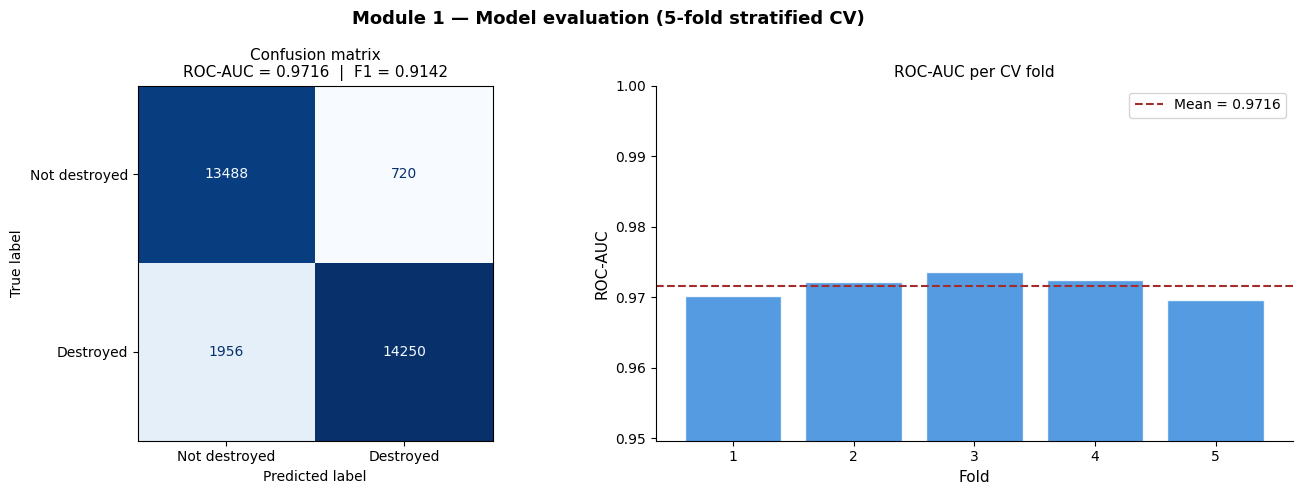

               precision    recall  f1-score   support

Not destroyed       0.87      0.95      0.91     14208
    Destroyed       0.95      0.88      0.91     16206

     accuracy                           0.91     30414
    macro avg       0.91      0.91      0.91     30414
 weighted avg       0.92      0.91      0.91     30414



In [17]:
y_pred = cross_val_predict(model, X, y, cv=cv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 1 — Model evaluation (5-fold stratified CV)', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y, y_pred),
    display_labels=['Not destroyed', 'Destroyed']
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(
    f'Confusion matrix\nROC-AUC = {auc_scores.mean():.4f}  |  F1 = {f1_scores.mean():.4f}',
    fontsize=11
)

auc_ymin = max(0.0, auc_scores.min() - 0.02)
axes[1].bar(range(1, 6), auc_scores, color='#378ADD', alpha=0.85, edgecolor='white')
axes[1].axhline(auc_scores.mean(), color='#A32D2D', linewidth=1.5,
                linestyle='--', label=f'Mean = {auc_scores.mean():.4f}')
axes[1].set_xlabel('Fold', fontsize=11)
axes[1].set_ylabel('ROC-AUC', fontsize=11)
axes[1].set_title('ROC-AUC per CV fold', fontsize=11)
axes[1].set_ylim(auc_ymin, 1.0)
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/01_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y, y_pred, target_names=['Not destroyed', 'Destroyed']))

## 8. SHAP explainability

> **Reviewer check:** Top features should be structural (Eaves, Vent Screen, Window Pane).
> If socioeconomic features dominate, the structural encoded columns were not present
> in the feature matrix — re-run from Section 2 to verify encoding happened before the join.

In [18]:
print('Computing SHAP values (TreeExplainer — exact Shapley values for tree ensembles)...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

mean_shap   = np.abs(shap_values).mean(axis=0)
shap_series = pd.Series(mean_shap, index=feature_names_clean).sort_values(ascending=False)

print('\nTop 10 features by mean |SHAP|:')
print(shap_series.head(10).round(4).to_string())

top5 = list(shap_series.head(5).index)
s_in_top5 = [f for f in top5 if f in structural_names]
print(f'\nStructural features in top 5 : {len(s_in_top5)}/5')
if len(s_in_top5) >= 2:
    print('Structural features dominating — thesis finding confirmed.')
else:
    print('WARNING: structural features not in top 5. Check ENC_COLS presence in FEATURE_COLS.')

Computing SHAP values (TreeExplainer — exact Shapley values for tree ensembles)...

Top 10 features by mean |SHAP|:
Eaves                                       2.2588
Window Pane                                 0.6315
Median Gross Rent                           0.4929
Vent Screen                                 0.4639
Median Hh Income                            0.3330
Exterior Siding                             0.2890
Fence Attached To Structure                 0.2836
Struct Age                                  0.2323
Patio Cover/Carport Attached To Structure   0.2018
Roof Construction                           0.1963

Structural features in top 5 : 3/5
Structural features dominating — thesis finding confirmed.


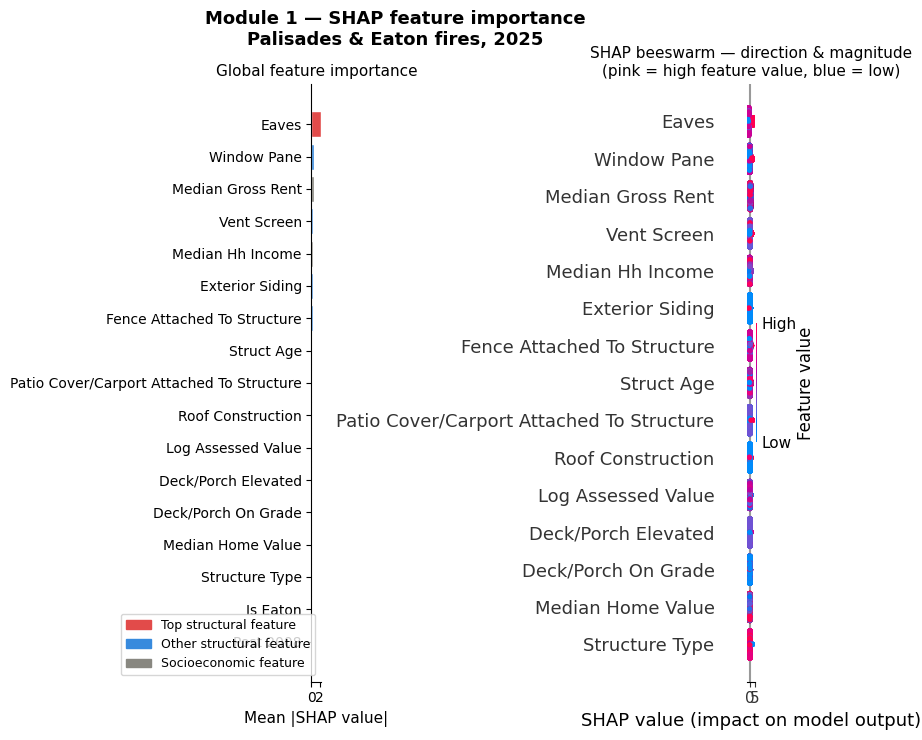

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Module 1 — SHAP feature importance\nPalisades & Eaton fires, 2025',
             fontsize=13, fontweight='bold')

shap_sorted = shap_series.sort_values(ascending=True)
colors = [
    '#E24B4A' if v == shap_sorted.max() else
    '#378ADD' if n in structural_names else '#888780'
    for n, v in shap_sorted.items()
]
axes[0].barh(shap_sorted.index, shap_sorted.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|', fontsize=11)
axes[0].set_title('Global feature importance', fontsize=11)
axes[0].legend(handles=[
    mpatches.Patch(color='#E24B4A', label='Top structural feature'),
    mpatches.Patch(color='#378ADD', label='Other structural feature'),
    mpatches.Patch(color='#888780', label='Socioeconomic feature'),
], fontsize=9, loc='lower right')
axes[0].spines[['top', 'right']].set_visible(False)

plt.sca(axes[1])
shap.summary_plot(
    shap_values, X, feature_names=feature_names_clean,
    plot_type='dot', show=False, max_display=15, color_bar=True
)
axes[1].set_title('SHAP beeswarm — direction & magnitude\n(pink = high feature value, blue = low)', fontsize=11)

plt.tight_layout()
plt.savefig('figures/02_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

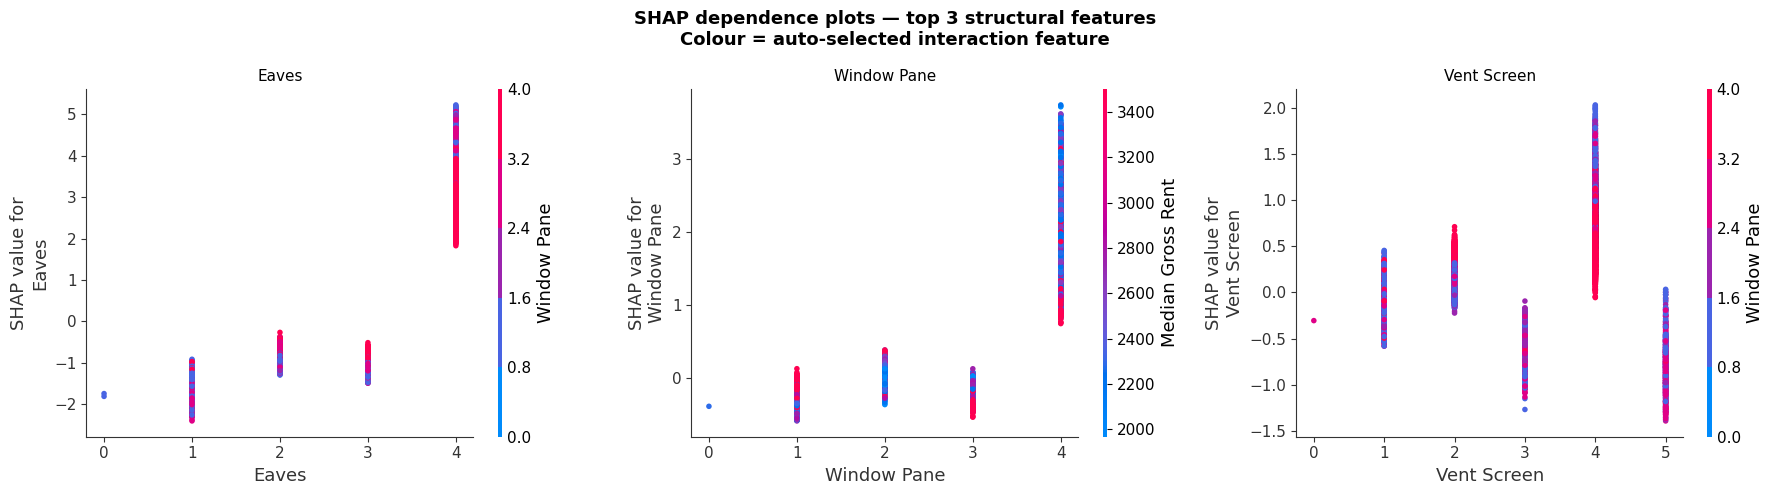

In [20]:
# ── SHAP dependence plots — top 3 structural features ─────────────────────────
struct_idx_shap = sorted(
    [(i, mean_shap[i]) for i, fn in enumerate(feature_names_clean) if fn in structural_names],
    key=lambda x: -x[1]
)[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP dependence plots — top 3 structural features\nColour = auto-selected interaction feature',
             fontsize=13, fontweight='bold')
for i, (idx, _) in enumerate(struct_idx_shap):
    shap.dependence_plot(idx, shap_values, X, feature_names=feature_names_clean,
                         ax=axes[i], show=False)
    axes[i].set_title(feature_names_clean[idx], fontsize=11)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/03_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Equity analysis

In [21]:
equity = (
    model_df.dropna(subset=['income_quintile'])
    .groupby('income_quintile', observed=True)['is_destroyed']
    .agg(['mean', 'count', 'sum'])
    .rename(columns={'mean': 'destruction_rate', 'count': 'total', 'sum': 'destroyed'})
    .reset_index()
)
equity['destruction_rate_pct'] = equity['destruction_rate'] * 100

print('Conditional destruction rate by income quintile:')
print(equity[['income_quintile', 'total', 'destroyed', 'destruction_rate_pct']].to_string(index=False))

present = equity[equity['total'] > 0]
gap = present.iloc[0]['destruction_rate_pct'] - present.iloc[-1]['destruction_rate_pct']
print(f'\nEquity gap ({present.iloc[0]["income_quintile"]} vs {present.iloc[-1]["income_quintile"]}): {gap:.1f} pp')
print('Q1 absent from fire zone: the fires burned exclusively in wealthy corridors.')
print('Prospective equity risk for Q1 tracts quantified in Module 3.')

Conditional destruction rate by income quintile:
income_quintile  total  destroyed  destruction_rate_pct
             Q2   1675       1169               69.7910
             Q3    175         13                7.4286
             Q4    565         74               13.0973
   Q5 (highest)  27999      14950               53.3948

Equity gap (Q2 vs Q5 (highest)): 16.4 pp
Q1 absent from fire zone: the fires burned exclusively in wealthy corridors.
Prospective equity risk for Q1 tracts quantified in Module 3.


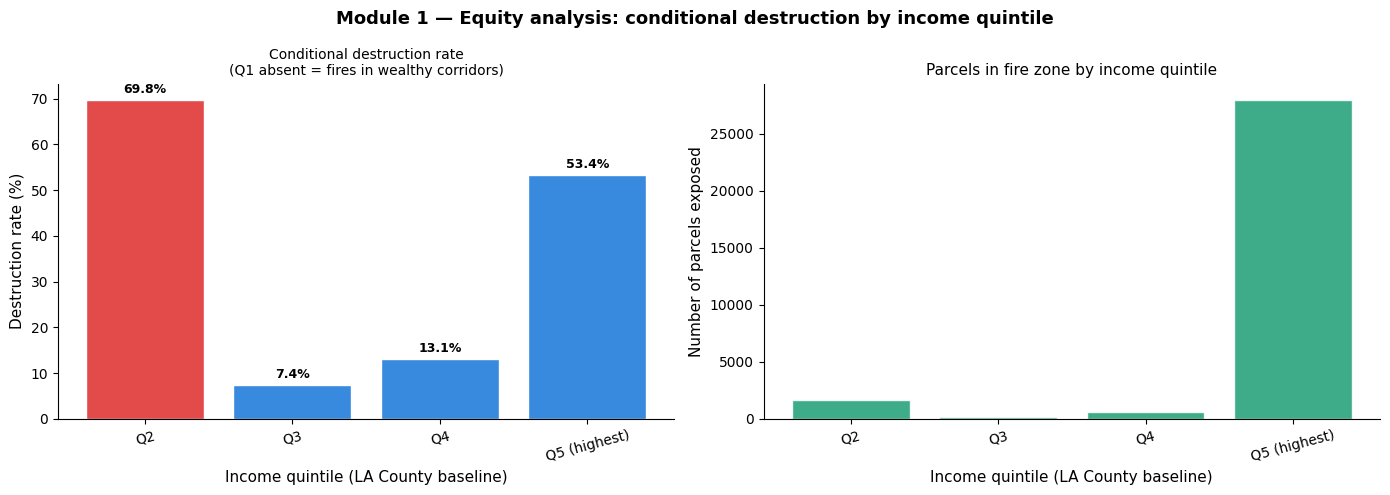

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 1 — Equity analysis: conditional destruction by income quintile',
             fontsize=13, fontweight='bold')

palette = ['#E24B4A' if i == equity['destruction_rate_pct'].idxmax() else '#378ADD'
           for i in equity.index]
bars = axes[0].bar(equity['income_quintile'].astype(str),
                   equity['destruction_rate_pct'], color=palette, edgecolor='white')
for bar, val in zip(bars, equity['destruction_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Income quintile (LA County baseline)', fontsize=11)
axes[0].set_ylabel('Destruction rate (%)', fontsize=11)
axes[0].set_title('Conditional destruction rate\n(Q1 absent = fires in wealthy corridors)', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].bar(equity['income_quintile'].astype(str), equity['total'],
            color='#1D9E75', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Income quintile (LA County baseline)', fontsize=11)
axes[1].set_ylabel('Number of parcels exposed', fontsize=11)
axes[1].set_title('Parcels in fire zone by income quintile', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/04_equity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Predicted destruction probability map

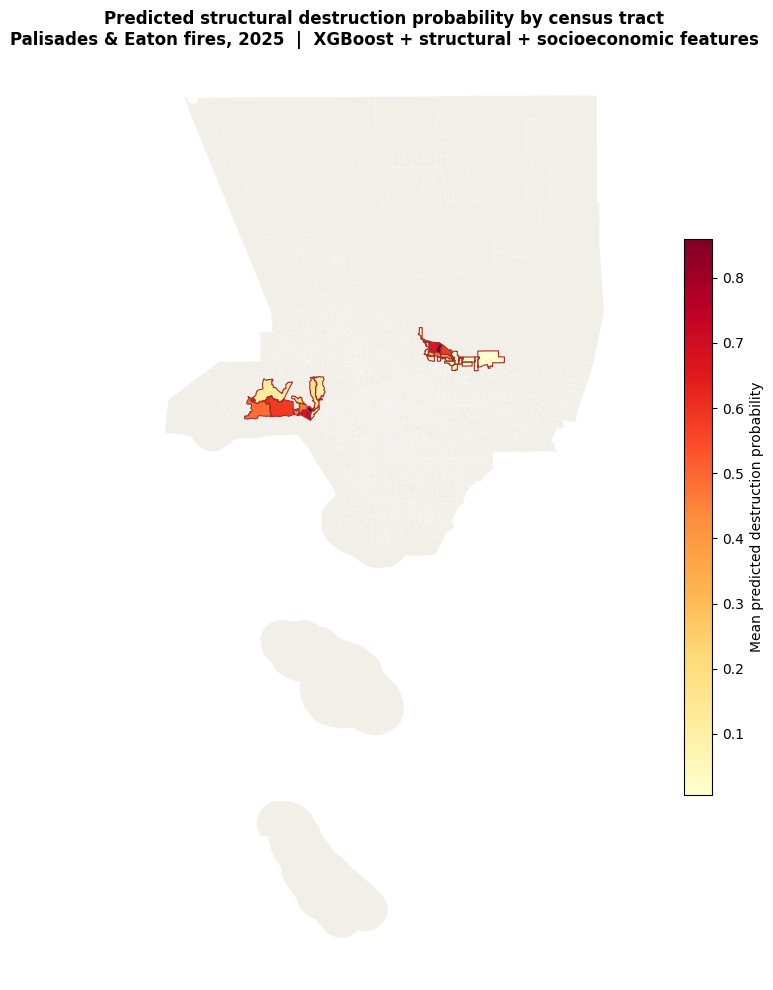

In [23]:
model_df['p_destroyed'] = model.predict_proba(X)[:, 1]
tract_risk = (
    model_df.dropna(subset=['GEOID', 'p_destroyed'])
    .groupby('GEOID')['p_destroyed'].mean().reset_index()
    .rename(columns={'p_destroyed': 'mean_p_destroyed'})
)
la_map = la_tracts.merge(tract_risk, on='GEOID', how='left')

fig, ax = plt.subplots(figsize=(12, 10))
la_map.plot(
    column='mean_p_destroyed', cmap='YlOrRd', legend=True,
    legend_kwds={'label': 'Mean predicted destruction probability', 'shrink': 0.6},
    missing_kwds={'color': '#F1EFE8', 'label': 'No DINS parcels'},
    ax=ax, linewidth=0.1, edgecolor='white'
)
la_map[la_map['mean_p_destroyed'].notna()].boundary.plot(ax=ax, color='#A32D2D', linewidth=0.8)
ax.set_title(
    'Predicted structural destruction probability by census tract\n'
    'Palisades & Eaton fires, 2025  |  XGBoost + structural + socioeconomic features',
    fontsize=12, fontweight='bold'
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('figures/05_risk_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Export outputs

In [25]:
export_cols = [
    '* Incident Name', '* Damage', 'damage_score', 'is_destroyed',
    'struct_age', 'post_2008', 'log_assessed_value', 'Latitude', 'Longitude',
    'GEOID', 'median_hh_income', 'median_home_value', 'median_gross_rent',
    'income_quintile', 'income_quintile_num'
]
export_cols = [c for c in export_cols if c in dins_joined.columns]

dins_joined[export_cols].dropna(subset=['GEOID']).to_csv('outputs/module1_output.csv', index=False)
pd.DataFrame(shap_values, columns=feature_names_clean).to_csv('outputs/shap_values.csv', index=False)
pd.DataFrame({'metric': ['ROC-AUC']*5+['F1']*5, 'fold': list(range(1,6))*2,
              'value': list(auc_scores)+list(f1_scores)}).to_csv('outputs/cv_results.csv', index=False)
pd.DataFrame({'rmsec': [rmsec], 'rmsep': [rmsep], 'gap': [gap]}).to_csv('outputs/overfitting_diagnostic.csv', index=False)
acs_panel.to_csv('outputs/acs_panel_2021_2022.csv', index=False)

print('Outputs exported:')
for f in ['outputs/module1_output.csv', 'outputs/shap_values.csv',
          'outputs/cv_results.csv', 'outputs/overfitting_diagnostic.csv',
          'outputs/acs_panel_2021_2022.csv']:
    print(f'  {f}')

if IN_COLAB:
    import shutil
    from google.colab import files
    # Archive only the 'outputs' directory to avoid issues with Google Drive specific files
    shutil.make_archive('module1_outputs', 'zip', root_dir='outputs')
    files.download('module1_outputs.zip')

Outputs exported:
  outputs/module1_output.csv
  outputs/shap_values.csv
  outputs/cv_results.csv
  outputs/overfitting_diagnostic.csv
  outputs/acs_panel_2021_2022.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>